In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(df.describe())
print(df['species'].value_counts())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X = iris.data    # no scaling needed for decision trees
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120, 4), Test: (30, 4)


In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

depths = range(1, 11)
cv_scores = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(clf, X_train, y_train, cv=5).mean()
    cv_scores.append(score)
    print(f"depth={d}: {score:.3f}")

best_depth = depths[cv_scores.index(max(cv_scores))]

depth=1: 0.667
depth=2: 0.925
depth=3: 0.933
depth=4: 0.942
depth=5: 0.942
depth=6: 0.942
depth=7: 0.942
depth=8: 0.942
depth=9: 0.942
depth=10: 0.942


In [5]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,
      target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



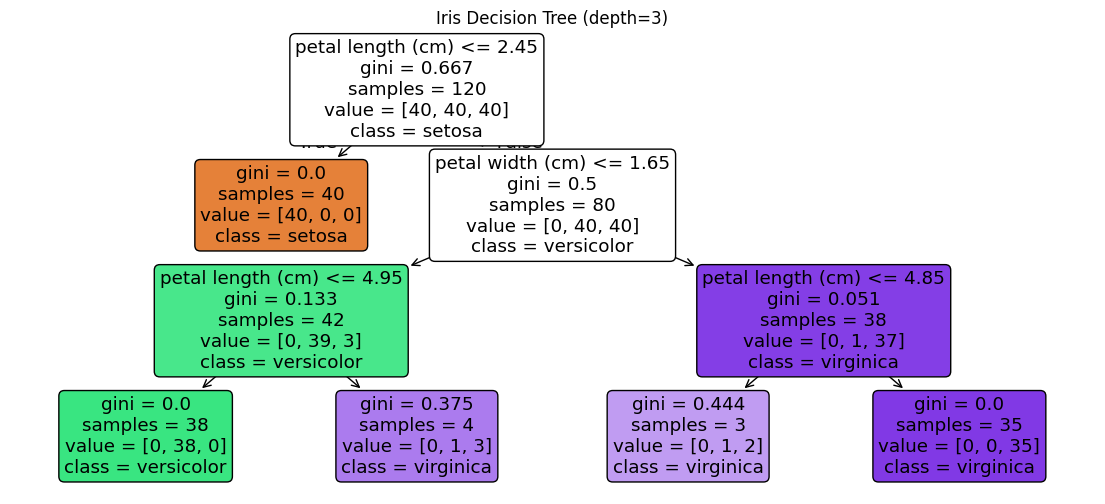

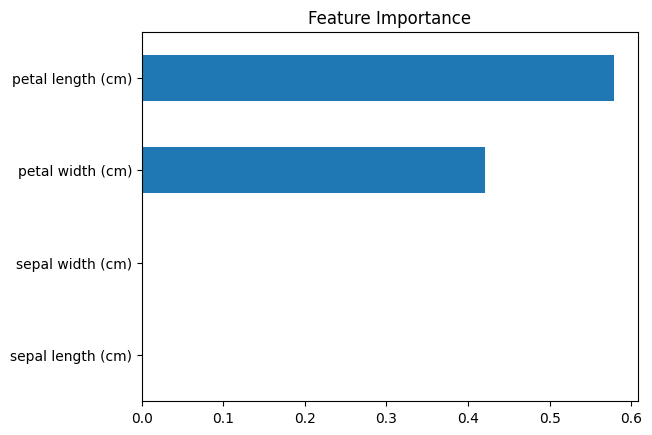

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Tree visualization
plt.figure(figsize=(14, 6))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,           # color nodes by class
          impurity=True,         # show gini at each node
          rounded=True)
plt.title("Iris Decision Tree (depth=3)")
plt.show()

# Feature importance bar chart
importances = pd.Series(clf.feature_importances_,
                        index=iris.feature_names).sort_values()
importances.plot.barh()
plt.title("Feature Importance")
plt.show()